# 04 - Phân tích khám phá dữ liệu (EDA)

Khám phá `data/processed/train_sach` (đã hợp nhất ở notebook 03) để tìm các đặc
điểm cần lưu ý trước khi thiết kế đặc trưng (notebook 05): tính đầy đủ của lưới
thời gian, cửa hàng mở muộn, mùa vụ, tác động ngày lễ/khuyến mãi/giá dầu, tính
dừng của chuỗi doanh số.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

THU_MUC_HIEN_TAI = Path.cwd()
GOC = THU_MUC_HIEN_TAI.parent if THU_MUC_HIEN_TAI.name == "notebooks" else THU_MUC_HIEN_TAI
sys.path.append(str(GOC / "src"))

from cau_hinh import DATA_PROCESSED, OUT_TABLES, OUT_FIGURES, tao_thu_muc
from spark_session import tao_spark
from pyspark.sql import functions as F

tao_thu_muc()
spark = tao_spark("04_EDA")

df = spark.read.parquet(str(DATA_PROCESSED / "train_sach"))
so_dong = df.count()
print("So dong train_sach:", so_dong)
df.printSchema()

MAU_CHINH = "#2a78d6"
MAU_PHU = "#eb6834"
MAU_LUOI = "#e1e0d9"
MAU_TRUC = "#c3c2b7"
MAU_CHU_PHU = "#52514e"
MAU_CHU_CHINH = "#0b0b0b"


def bo_khung(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(MAU_TRUC)
    ax.tick_params(colors=MAU_CHU_PHU)
    ax.set_axisbelow(True)

So dong train_sach: 3000888
root
 |-- store_nbr: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- id: integer (nullable = true)
 |-- family: string (nullable = true)
 |-- sales: double (nullable = true)
 |-- onpromotion: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- type: string (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- gia_dau: double (nullable = true)
 |-- la_ngay_le: boolean (nullable = true)
 |-- la_su_kien_dac_biet: boolean (nullable = true)
 |-- transactions: integer (nullable = true)



## 1. Tính đầy đủ của lưới thời gian

Kiểm tra xem `train` có phải lưới đầy đủ `so_ngay x so_to_hop(store, family)` hay
không — nếu đúng bằng số dòng thực tế thì mọi tổ hợp cửa hàng/nhóm hàng đều có 1
dòng cho mỗi ngày (kể cả những ngày doanh số = 0), tức **không thiếu dòng**, nhưng
vẫn có thể "thiếu" theo nghĩa nghiệp vụ (cửa hàng chưa mở).

In [2]:
so_ngay = df.select("date").distinct().count()
so_to_hop = df.select("store_nbr", "family").distinct().count()
print(f"So ngay: {so_ngay} | So to hop (store,family): {so_to_hop} | Tich: {so_ngay * so_to_hop}")
print("Luoi day du (tich == so dong thuc te):", so_ngay * so_to_hop == so_dong)

So ngay: 1684 | So to hop (store,family): 1782 | Tich: 3000888
Luoi day du (tich == so dong thuc te): True


## 2. Tỷ lệ doanh số bằng 0

In [3]:
so_zero = df.filter(F.col("sales") == 0).count()
print(f"Ty le sales = 0 toan bo: {so_zero}/{so_dong} ({100*so_zero/so_dong:.2f}%)")

theo_family_zero = (df.groupBy("family")
                     .agg(F.avg((F.col("sales") == 0).cast("double")).alias("ty_le_zero"))
                     .orderBy(F.desc("ty_le_zero"))
                     .toPandas())
print("5 nhom hang co ty le doanh so = 0 cao nhat:")
print(theo_family_zero.head())

Ty le sales = 0 toan bo: 939130/3000888 (31.30%)


5 nhom hang co ty le doanh so = 0 cao nhat:
                       family  ty_le_zero
0                       BOOKS    0.969550
1                   BABY CARE    0.941310
2  SCHOOL AND OFFICE SUPPLIES    0.740829
3             HOME APPLIANCES    0.735176
4                  LADIESWEAR    0.598465


## 3. Cửa hàng mở muộn (leading zero)

Tìm ngày đầu tiên mỗi cửa hàng có doanh số > 0. Nếu ngày này muộn hơn đáng kể so
với ngày bắt đầu dữ liệu (loại trừ hiệu ứng ngày Tết Dương lịch 01/01 khi hầu hết
cửa hàng đóng cửa), đó là dấu hiệu cửa hàng **mở sau** khi dữ liệu bắt đầu ghi
nhận — các dòng doanh số = 0 trước đó **không phản ánh nhu cầu thực**, cần loại bỏ
khi huấn luyện mô hình ở notebook 05/06 (nếu không sẽ làm méo mô hình).

In [4]:
ngay_min_toan_cuc = df.select(F.min("date")).first()[0]
nguong = ngay_min_toan_cuc + pd.Timedelta(days=30)

ngay_dau_co_ds = (df.filter(F.col("sales") > 0)
                  .groupBy("store_nbr").agg(F.min("date").alias("ngay_dau_co_doanh_so")))

cua_hang_mo_muon = (ngay_dau_co_ds.filter(F.col("ngay_dau_co_doanh_so") > F.lit(nguong))
                     .orderBy("ngay_dau_co_doanh_so").toPandas())
print(f"Ngay bat dau du lieu: {ngay_min_toan_cuc}. Nguong xac dinh 'mo muon': sau {nguong}.")
print(f"So cua hang mo muon: {len(cua_hang_mo_muon)}")
print(cua_hang_mo_muon)

cua_hang_mo_muon.to_csv(OUT_TABLES / "eda_cua_hang_mo_muon.csv", index=False, encoding="utf-8-sig")

Ngay bat dau du lieu: 2013-01-01. Nguong xac dinh 'mo muon': sau 2013-01-31.
So cua hang mo muon: 8
   store_nbr ngay_dau_co_doanh_so
0         36           2013-05-09
1         53           2014-05-29
2         20           2015-02-13
3         29           2015-03-20
4         21           2015-07-24
5         42           2015-08-21
6         22           2015-10-09
7         52           2017-04-20


## 4. Xu hướng chuỗi thời gian (tổng doanh số toàn quốc theo ngày)

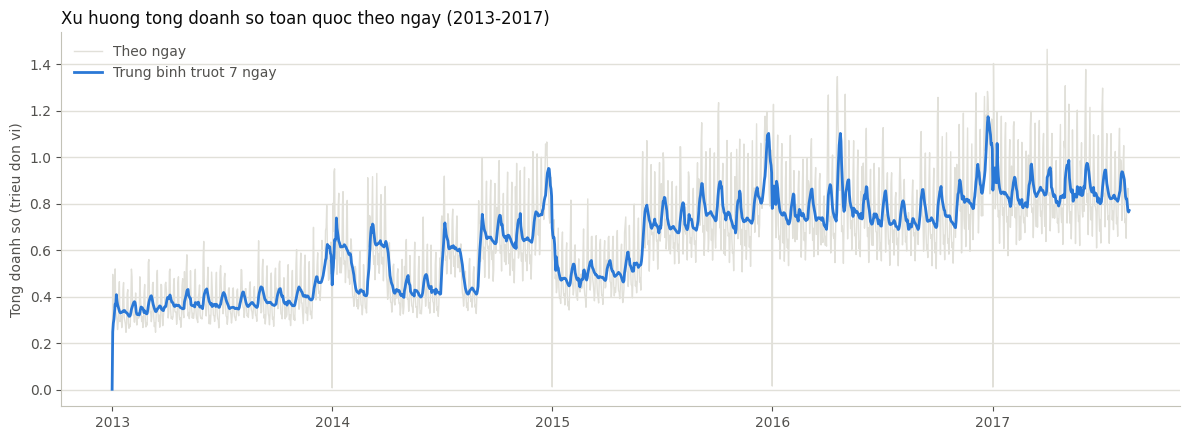

In [5]:
theo_ngay = (df.groupBy("date").agg(F.sum("sales").alias("tong_doanh_so"))
             .orderBy("date").toPandas())
theo_ngay["date"] = pd.to_datetime(theo_ngay["date"])
theo_ngay["trung_binh_truot_7"] = theo_ngay["tong_doanh_so"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(theo_ngay["date"], theo_ngay["tong_doanh_so"] / 1e6, color=MAU_LUOI, linewidth=1, label="Theo ngay")
ax.plot(theo_ngay["date"], theo_ngay["trung_binh_truot_7"] / 1e6, color=MAU_CHINH, linewidth=2,
        label="Trung binh truot 7 ngay")
ax.set_ylabel("Tong doanh so (trieu don vi)", color=MAU_CHU_PHU)
ax.set_title("Xu huong tong doanh so toan quoc theo ngay (2013-2017)", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
ax.legend(frameon=False, labelcolor=MAU_CHU_PHU)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "eda_xu_huong_theo_ngay.png", dpi=150)
plt.show()

## 5. Kiểm định tính dừng (Augmented Dickey-Fuller)

In [6]:
adf_stat, adf_p, *_ = adfuller(theo_ngay["tong_doanh_so"])
print(f"ADF statistic = {adf_stat:.4f}, p-value = {adf_p:.4f}")
if adf_p < 0.05:
    print("=> Bac bo H0 o muc 5%: chuoi co the xem la dung (stationary).")
else:
    print("=> Khong du bang chung bac bo H0 o muc 5%: chuoi co kha nang KHONG dung",
          "(phu hop voi xu huong tang quan sat duoc o bieu do tren).",
          "Can dua them dac trung xu huong/mua vu (lag, rolling, ngay/thang/nam) o buoc 05",
          "vi Random Forest khong tu dong ngoai suy xu huong nhu mo hinh ARIMA.")

ADF statistic = -2.6162, p-value = 0.0897
=> Khong du bang chung bac bo H0 o muc 5%: chuoi co kha nang KHONG dung (phu hop voi xu huong tang quan sat duoc o bieu do tren). Can dua them dac trung xu huong/mua vu (lag, rolling, ngay/thang/nam) o buoc 05 vi Random Forest khong tu dong ngoai suy xu huong nhu mo hinh ARIMA.


## 6. Mùa vụ theo thứ trong tuần

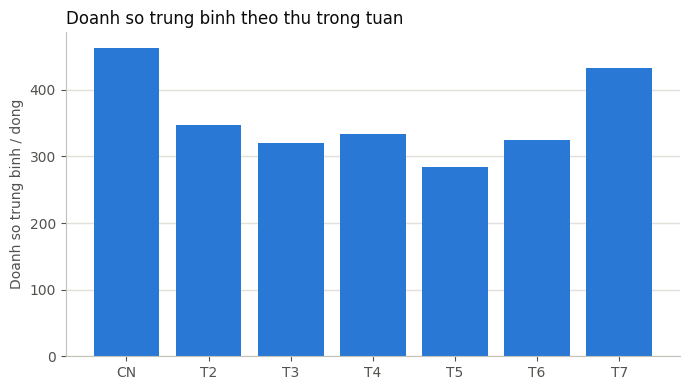

In [7]:
TEN_THU = {1: "CN", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6", 7: "T7"}
theo_thu = (df.withColumn("thu", F.dayofweek("date"))
            .groupBy("thu").agg(F.avg("sales").alias("doanh_so_tb"))
            .orderBy("thu").toPandas())
theo_thu["ten_thu"] = theo_thu["thu"].map(TEN_THU)
theo_thu.to_csv(OUT_TABLES / "eda_theo_thu.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(theo_thu["ten_thu"], theo_thu["doanh_so_tb"], color=MAU_CHINH)
ax.set_ylabel("Doanh so trung binh / dong", color=MAU_CHU_PHU)
ax.set_title("Doanh so trung binh theo thu trong tuan", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "eda_theo_thu.png", dpi=150)
plt.show()

## 7. Ảnh hưởng ngày lễ và sự kiện đặc biệt

In [8]:
theo_le = (df.groupBy("la_ngay_le")
           .agg(F.avg("sales").alias("doanh_so_tb"), F.count("*").alias("so_dong"))
           .toPandas())
theo_su_kien = (df.groupBy("la_su_kien_dac_biet")
                .agg(F.avg("sales").alias("doanh_so_tb"), F.count("*").alias("so_dong"))
                .toPandas())
print("Theo ngay le:\n", theo_le)
print("\nTheo su kien dac biet:\n", theo_su_kien)

Theo ngay le:
    la_ngay_le  doanh_so_tb  so_dong
0        True   423.469874   151734
1       False   354.277155  2849154

Theo su kien dac biet:
    la_su_kien_dac_biet  doanh_so_tb  so_dong
0                 True   425.024432    98010
1                False   355.505229  2902878


## 8. Ảnh hưởng khuyến mãi (`onpromotion`)

In [9]:
tuong_quan_km = df.stat.corr("onpromotion", "sales")
print("He so tuong quan onpromotion vs sales:", round(tuong_quan_km, 4))

theo_km = (df.withColumn("co_khuyen_mai", F.col("onpromotion") > 0)
           .groupBy("co_khuyen_mai").agg(F.avg("sales").alias("doanh_so_tb")).toPandas())
print(theo_km)

He so tuong quan onpromotion vs sales: 0.4279


   co_khuyen_mai  doanh_so_tb
0           True  1137.693730
1          False   158.246681


## 9. Tương quan giá dầu với tổng doanh số ngày

Ecuador là nền kinh tế phụ thuộc xuất khẩu dầu mỏ, nên giá dầu thường được dùng
làm đặc trưng kinh tế vĩ mô trong bộ dữ liệu này.

**Lưu ý diễn giải:** tương quan quan sát được rất có thể là *giả tương quan* do cả
hai chuỗi cùng biến thiên theo thời gian (giá dầu giảm mạnh 2014-2016 trong khi
tổng doanh số tăng dần theo xu hướng chung ở mục 4), không hẳn phản ánh quan hệ
nhân quả trực tiếp. Không nên diễn giải "giá dầu giảm khiến doanh số tăng" chỉ từ
hệ số tương quan thô này — nếu dùng `gia_dau` làm đặc trưng ở bước 05, nên cân nhắc
đưa cùng với đặc trưng xu hướng/thời gian để mô hình tách được 2 hiệu ứng.

He so tuong quan gia dau vs tong doanh so ngay: -0.628


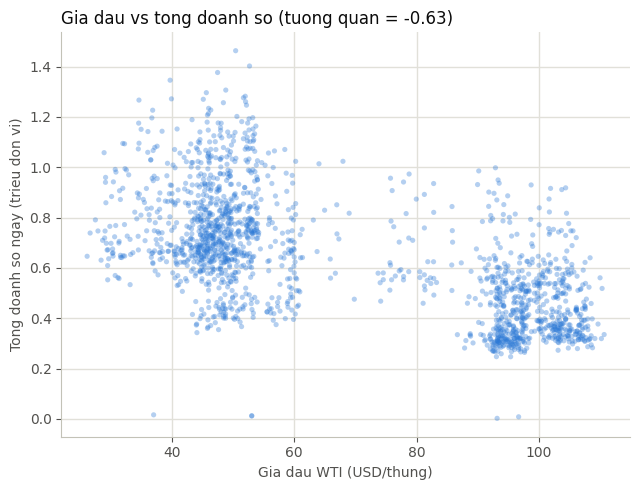

In [10]:
theo_ngay_gia_dau = (df.groupBy("date")
                     .agg(F.sum("sales").alias("tong_doanh_so"), F.first("gia_dau").alias("gia_dau"))
                     .toPandas())
tuong_quan_dau = theo_ngay_gia_dau["tong_doanh_so"].corr(theo_ngay_gia_dau["gia_dau"])
print("He so tuong quan gia dau vs tong doanh so ngay:", round(tuong_quan_dau, 4))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(theo_ngay_gia_dau["gia_dau"], theo_ngay_gia_dau["tong_doanh_so"] / 1e6,
           color=MAU_CHINH, alpha=0.35, s=14, edgecolors="none")
ax.set_xlabel("Gia dau WTI (USD/thung)", color=MAU_CHU_PHU)
ax.set_ylabel("Tong doanh so ngay (trieu don vi)", color=MAU_CHU_PHU)
ax.set_title(f"Gia dau vs tong doanh so (tuong quan = {tuong_quan_dau:.2f})", color=MAU_CHU_CHINH, loc="left")
ax.grid(color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "eda_gia_dau_vs_doanh_so.png", dpi=150)
plt.show()

## 10. Doanh số theo loại cửa hàng (`type`)

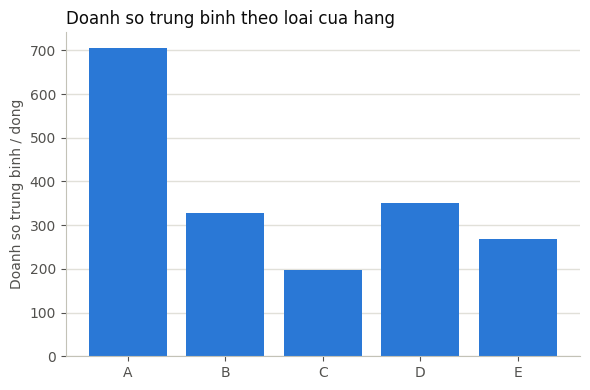

In [11]:
theo_loai = (df.groupBy("type").agg(F.avg("sales").alias("doanh_so_tb")).orderBy("type").toPandas())
theo_loai.to_csv(OUT_TABLES / "eda_theo_loai_cua_hang.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(theo_loai["type"], theo_loai["doanh_so_tb"], color=MAU_CHINH)
ax.set_ylabel("Doanh so trung binh / dong", color=MAU_CHU_PHU)
ax.set_title("Doanh so trung binh theo loai cua hang", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "eda_theo_loai_cua_hang.png", dpi=150)
plt.show()

## 11. Tóm tắt phát hiện chính (đầu vào cho notebook 05)

1. **Lưới thời gian đầy đủ** (`so_ngay x so_to_hop == so_dong`) — không thiếu dòng,
   nhưng doanh số = 0 chiếm ~31%, một phần do **cửa hàng mở muộn** (vd. cửa hàng 52
   mở 2017-04-20) → cần cắt bỏ đoạn đầu doanh số = 0 trước ngày mở thực tế của từng
   cửa hàng khi tạo đặc trưng/huấn luyện, nếu không mô hình sẽ học sai lệch nhu cầu.
2. **Chuỗi có xu hướng tăng** và (theo kiểm định ADF) khả năng **không dừng** →
   cần đặc trưng lag/rolling/thời gian (năm, tháng, thứ) thay vì chỉ dùng giá trị thô.
3. **Mùa vụ theo thứ trong tuần** rõ rệt (cuối tuần cao hơn giữa tuần).
4. **Ngày lễ và khuyến mãi** đều có doanh số trung bình cao hơn ngày thường —
   `la_ngay_le`, `onpromotion` là đặc trưng có giá trị.
5. **Giá dầu tương quan âm** với tổng doanh số, nhưng khả năng cao là **giả tương
   quan** do cùng biến thiên theo thời gian (xem lưu ý ở mục 9) — nếu dùng làm đặc
   trưng, nên kết hợp cùng đặc trưng xu hướng/thời gian để tránh mô hình học nhầm
   quan hệ nhân quả.
6. **Loại cửa hàng (`type`)** có khác biệt doanh số trung bình rõ rệt — đặc trưng phân loại hữu ích.

In [12]:
spark.stop()